### Day 1: Data Preprocessing and Feature Engineering (Exploratory Data Analysis)

1. Part 1: Let's understand the Data we are given

2. Part 2: Prepare data for Modeling, add Features

Full List of Possible things to see in the Data:

ML industry course

1. new categories appear at testing time, how will the model know how to establish a relationship between the value of the feature and the actual target

2. two features might be perfectly correlated or anti-correlated, knowing one feature might perfectly inform you on the value of another, no need for both

3. Duplicates in the dataframe: we always need to have an ID (for classification/regression it's usually one key, for time series is an id and a time index)

4. perfect correlation in terms of whether the feature is present or not 

5. Missing values, completely at random, at random, not at random

6. Examples of features that are leaking the target, might not be present at production time

7.	Inconsistent categorical labels
Same concept written differently (e.g. “NY”, “New York”, “new york”). Very common in operational data.

8.	Implicit hierarchies inside categories
Values that belong to a taxonomy (e.g. product category → subcategory) but stored as flat strings.

9.	Unit inconsistencies
Same feature stored in different units (€, $, thousands vs units, meters vs km).

10.	Data drift across time
Distribution of a feature changes by period (e.g. pre/post policy change). Even visible just with simple plots.

11.	Rare categories / long tail
Many categories with very few observations.

12.	Mixed types inside a column
Numeric stored as strings, free text mixed with codes.

13.	Invalid or impossible values
Negative ages, future dates, zero where impossible.

14.	Truncated / capped values
Operational limits (e.g. max credit limit stored as 999999).

15.	Sampling bias / selection bias
Dataset represents only approved customers, only active users, etc.

16.	Multiple rows per entity when you expect one
Hidden panel structure.

17.	Time misalignment
Features measured after the event you want to predict.

18.	Sparse indicator explosions
Hundreds of mostly-zero columns from upstream systems.

19.	Business process artifacts
Values driven by workflow rules rather than real behavior (e.g. default flags set after manual review).

In [1]:
cd ..

/Users/tommasoguerrini/Projects/ml_industry_course


##### Imports

In [ ]:
import tabulate
import os
import seaborn as sns
from datetime import datetime
import matplotlib.pyplot as plt
plt.style.use('bmh')
import numpy as np
import pandas as pd
pd.options.display.max_columns = 200
pd.options.display.max_colwidth = 250

def show(df, n_rows=5):
    print(tabulate.tabulate(df.head(n_rows), headers='keys', tablefmt='psql'))

### Dataset Overview



<div style="max-height:300px; overflow:auto; border:1px solid #ddd; padding:6px">

| Dataset | Task | Issues file (rows x cols) | Main injected issues |
|---|---|---:|---|
| Adult Income | Binary classification (`class`: `<=50K` / `>50K`) | `adult_income_issues.csv` (50,317 x 36) | Missingness, leakage, duplicates, mixed types, invalid values, rare/new categories, sparse indicators, process artifacts |
| Ames Housing | Regression (`sale_price`) | `ames_housing_issues.csv` (1,576 x 84) | Truncation/capping, multiple rows per entity |
| Retail Panel | Time-aware store-level forecasting (`sales`) | `retail_panel_issues.csv` (22,800 x 9) | Data drift, time misalignment, process artifacts |

</div>

### 1) Adult Income (`adult_income_issues.csv`)
Person-level application/income dataset with added operational and quality issues. Target is binary: `class` is either `<=50K` or `>50k`. 

<div style="max-height:300px; overflow:auto; border:1px solid #ddd; padding:6px">

| person_id | age | occupation | hours_per_week | native_country | class | split | post_adjudication_risk_code | duplicate_application_flag | record_written_at |
|---|---:|---|---:|---|---|---|---:|---:|---|
| 1 | 25 | Machine-op-inspct | 40 | United-States | <=50K | train | 0.005 | 0 | 2026-01-20 03:21:27 |
| 2 | 38 | Farming-fishing | 50 | United-States | <=50K | train | 0.021 | 0 | 2026-02-08 22:54:51 |
| 3 | 28 | Protective-serv | 40 | US | >50K | test | 0.992 | 0 | 2026-01-23 11:09:29 |

</div>

### 2) Ames Housing (`ames_housing_issues.csv`)
Property-level housing dataset for sale price prediction, with panel-style duplicates and capped derived values. Target is continuous `sale_price`.

<div style="max-height:300px; overflow:auto; border:1px solid #ddd; padding:6px">

| property_id | mszoning | neighborhood | lotarea | grlivarea | sale_price | reported_max_loan | record_extract_month |
|---|---|---|---:|---:|---:|---:|---|
| 1 | RL | CollgCr | 8450 | 1710 | 208500.0 | 187650.0 | 2024-01 |
| 2 | RL | Veenker | 9600 | 1262 | 181500.0 | 163350.0 | 2024-01 |
| 3 | RL | CollgCr | 11250 | 1786 | 223500.0 | 201150.0 | 2024-01 |

</div>

### 3) Retail Panel (`retail_panel_issues.csv`)
Daily store panel with promotion/inventory context and injected temporal/business-process issues. Target is continuous `sales`.

<div style="max-height:300px; overflow:auto; border:1px solid #ddd; padding:6px">

| store_id | date | inventory_units | promotion_discount_pct | sales | inventory_after_restock | manual_override_flag | workflow_route_code |
|---:|---|---:|---:|---:|---:|---:|---|
| 1 | 2023-01-01 | 561 | 7.59 | 143 | 702.0 | 0 | AUTO_PASS |
| 1 | 2023-01-02 | 702 | 11.79 | 139 | 423.0 | 0 | AUTO_PASS |
| 1 | 2023-01-03 | 423 | 1.43 | 88 | 448.0 | 0 | AUTO_PASS |

</div>

In [3]:
adult = pd.read_csv("day1/generated/adult_income_issues.csv")
ames = pd.read_csv("day1/generated/ames_housing_issues.csv")
retail = pd.read_csv("day1/generated/retail_panel_issues.csv")

## Data Issues

#### 1. Duplicates

Duplicates can artificially inflate sample size, bias learned patterns, and create train/test contamination if the same entity appears in both sets.



##### See the Issue

In [50]:
print("2 rows completely equal, no need to keep both: \n")

show(adult.loc[adult.duplicated(keep=False)].sort_values('person_id').head(2))

2 rows completely equal, no need to keep both: 

+------+-------------+-------+-----------------+------------------+----------------+----------------+---------------+------------------+-------------+------------------+----------------+---------+---------+--------------------------------------------------------------+-------------------------------+--------------------------+-----------------------------+----------------------------+-------------------------------+--------------------------------+------------------------------+-------------------------+------------------------------+--------------------------------+------------------------+--------------------------+----------------+------------------------+-----------------------------+-------------------+---------------------+--------------+---------------------+
|      |   person_id |   age |   education_num |   hours_per_week |   capital_gain |   capital_loss | occupation    | native_country   | workclass   | marital_status   | rela

In [51]:
dup_id = adult.groupby('person_id').nunique().max(axis=1).rename('nunique').reset_index().query('nunique > 1').person_id.iloc[0]
print(f"Same person_id, different values in other columns: {', '.join(adult.query(f"person_id == {dup_id}").nunique(axis=0).rename('n_rows').reset_index().query('n_rows > 1')['index'].tolist())}")

show(adult.query(f"person_id == {dup_id}"))

Same person_id, different values in other columns: hours_per_week, capital_gain, record_written_at
+------+-------------+-------+-----------------+------------------+----------------+----------------+--------------+------------------+-------------+------------------+----------------+---------+---------+--------------------------------------------------------------+-------------------------------+--------------------------+-----------------------------+----------------------------+-------------------------------+--------------------------------+------------------------------+-------------------------+------------------------------+--------------------------------+------------------------+--------------------------+----------------+------------------------+-----------------------------+-------------------+---------------------+--------------+---------------------+
|      |   person_id |   age |   education_num |   hours_per_week |   capital_gain |   capital_loss | occupation   | native_c

##### Spot the issue automatically

In [52]:
print(f"Number of rows in dataset: {len(adult)}. Number of unique rows in dataset: {len(adult.drop_duplicates())}.\n")

print(f"Number of rows in dataset: {len(adult)}. Number of unique ids in dataset: {adult['person_id'].nunique(dropna=True)}.\n\n")

Number of rows in dataset: 9271. Number of unique rows in dataset: 9162.

Number of rows in dataset: 9271. Number of unique ids in dataset: 9000.




#### 2. Impossible Values

Based on the column name (and sometimes on a description) we might know what values to expect. If a variable is "salary" or "age" you won't expect negative values for instance.

##### See the Issue

In [4]:
def count_and_show(df, mask, cols, label, n=5):
    print(f"{label}: {int(mask.sum())} rows")
    if mask.sum() > 0:
        show(df.loc[mask, cols].head(n), n)

In [5]:
adult_age = pd.to_numeric(adult["age"], errors="coerce")
adult_bad_age = (adult_age > 120) | (adult_age < 0)

adult_cols = ["person_id", "age", "record_written_at"] if "record_written_at" in adult.columns else ["person_id", "age"]
count_and_show(adult, adult_bad_age, adult_cols, "Adult - invalid age (<0 or >120)", n=10)


Adult - invalid age (<0 or >120): 85 rows
+-----+-------------+-------+---------------------+
|     |   person_id |   age | record_written_at   |
|-----+-------------+-------+---------------------|
| 126 |         127 |    -2 | 2026-01-30 13:41:26 |
| 141 |         142 |    -3 | 2026-02-06 00:04:51 |
| 161 |         162 |   123 | 2026-01-09 22:51:42 |
| 169 |         170 |    -4 | 2026-01-21 16:10:30 |
| 189 |         190 |    -4 | 2026-01-15 22:45:03 |
| 197 |         198 |    -4 | 2026-01-06 20:36:48 |
| 262 |         263 |   122 | 2026-01-29 09:33:16 |
| 341 |         342 |    -5 | 2026-01-20 23:42:32 |
| 375 |         376 |   121 | 2026-01-28 02:48:55 |
| 397 |         398 |    -6 | 2026-01-01 06:34:50 |
+-----+-------------+-------+---------------------+


In [6]:
lot_num = pd.to_numeric(ames["lot_area"], errors="coerce")
count_and_show(ames, lot_num == 0, ["property_id", "lot_area"], "Ames - lot area == 0")

garage_num = pd.to_numeric(ames["garage_area"], errors="coerce")
count_and_show(ames, garage_num < 0, ["property_id", "garage_area"], "Ames - negative garage area")

year_num = pd.to_numeric(ames["year_built"], errors="coerce")
current_year = pd.Timestamp.today().year
count_and_show(ames, year_num > current_year, ["property_id", "year_built"], "Ames - future construction year")

Ames - lot area == 0: 31 rows
+-----+---------------+------------+
|     |   property_id |   lot_area |
|-----+---------------+------------|
|  43 |            44 |          0 |
| 109 |           110 |          0 |
| 349 |           350 |          0 |
| 371 |           372 |          0 |
| 398 |           399 |          0 |
+-----+---------------+------------+
Ames - negative garage area: 19 rows
+-----+---------------+---------------+
|     |   property_id |   garage_area |
|-----+---------------+---------------|
| 311 |           312 |          -353 |
| 320 |           321 |          -367 |
| 337 |           338 |          -249 |
| 409 |           410 |          -535 |
| 535 |           536 |          -301 |
+-----+---------------+---------------+
Ames - future construction year: 28 rows
+-----+---------------+--------------+
|     |   property_id |   year_built |
|-----+---------------+--------------|
| 110 |           111 |         2050 |
| 148 |           149 |         2094 |
| 22

In [56]:
disc_num = pd.to_numeric(retail["promotion_discount_pct"], errors="coerce")
inv_num = pd.to_numeric(retail["inventory_units"], errors="coerce")

count_and_show(
    retail,
    (disc_num > 100) | (disc_num < 0),
    ["store_id", "date", "promotion_discount_pct"],
    "Retail - invalid discount (<0 or >100)"
)

count_and_show(
    retail,
    inv_num < 0,
    ["store_id", "date", "inventory_units"],
    "Retail - negative inventory"
)

Retail - invalid discount (<0 or >100): 324 rows
+-----+------------+------------+--------------------------+
|     |   store_id | date       |   promotion_discount_pct |
|-----+------------+------------+--------------------------|
|  37 |          1 | 2023-02-07 |                   122.34 |
| 159 |          1 | 2023-06-09 |                   145.63 |
| 211 |          1 | 2023-07-31 |                   147.95 |
| 223 |          1 | 2023-08-12 |                   120.87 |
| 464 |          2 | 2023-03-26 |                   115.2  |
+-----+------------+------------+--------------------------+
Retail - negative inventory: 182 rows
+-----+------------+------------+-------------------+
|     |   store_id | date       |   inventory_units |
|-----+------------+------------+-------------------|
|  42 |          1 | 2023-02-12 |              -293 |
|  76 |          1 | 2023-03-18 |              -202 |
| 105 |          1 | 2023-04-16 |              -362 |
| 124 |          1 | 2023-05-05 |       

##### Spot the Issue Automatically

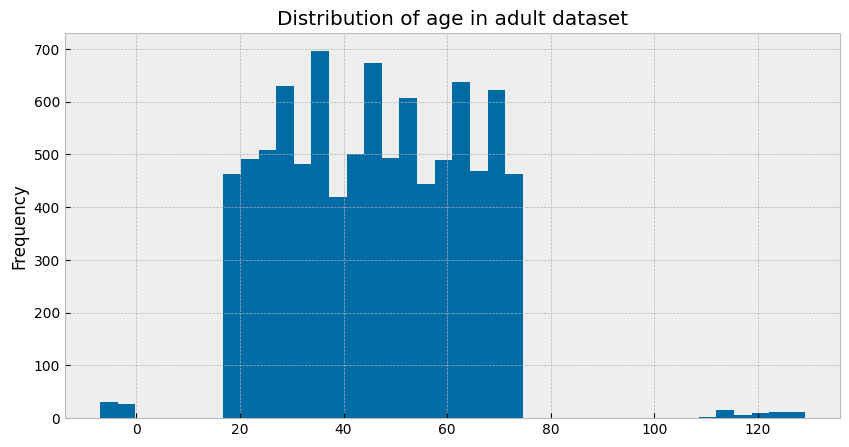

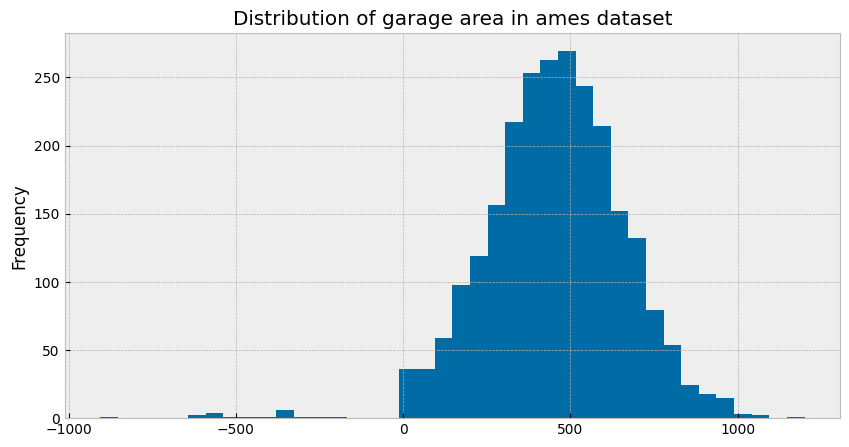

In [7]:
plt.style.use('tableau-colorblind10')
fig = plt.figure(figsize=(10, 5))
adult_age.plot(kind='hist', bins=40, title='Distribution of age in adult dataset');
fig = plt.figure(figsize=(10, 5))
garage_num.plot(kind='hist', bins=40, title='Distribution of garage area in ames dataset');

#### 3. Mixed Types

A column that should be numeric but contains strings breaks aggregations, imputations, scaling, and can silently produce wrong results.

In [58]:
adult_hours_raw = adult["hours_per_week"].astype("string").str.strip()
adult_hours_num = pd.to_numeric(adult_hours_raw, errors="coerce")
adult_hours_mixed = adult_hours_raw.notna() & adult_hours_num.isna()

adult_cols = ["person_id", "hours_per_week"]
if "record_written_at" in adult.columns:
    adult_cols.append("record_written_at")

count_and_show(
    adult,
    adult_hours_mixed,
    adult_cols,
    "Adult - mixed types in hours_per_week",
    n=10
)


adult.loc[adult_hours_mixed, "hours_per_week"].value_counts().head(10)

Adult - mixed types in hours_per_week: 272 rows
+-----+-------------+------------------+---------------------+
|     |   person_id | hours_per_week   | record_written_at   |
|-----+-------------+------------------+---------------------|
|  13 |          14 | 21h              | 2026-01-05 21:25:57 |
|  32 |          33 | 27h              | 2026-01-02 17:59:10 |
|  60 |          61 | 34h              | 2026-01-28 08:12:37 |
|  79 |          80 | 17h              | 2026-01-23 20:25:46 |
| 150 |         151 | 46h              | 2026-01-02 23:40:34 |
| 220 |         221 | 52h              | 2026-02-02 12:52:42 |
| 245 |         246 | 62h              | 2026-02-02 22:40:16 |
| 284 |         285 | 53h              | 2026-02-09 21:18:31 |
| 321 |         322 | 32h              | 2026-01-31 11:37:52 |
| 350 |         351 | 67h              | 2026-02-04 14:59:22 |
+-----+-------------+------------------+---------------------+


hours_per_week
17h    10
23h     9
64h     9
15h     9
22h     9
31h     8
54h     8
21h     7
62h     7
32h     7
Name: count, dtype: int64

In [60]:
adult_age_raw = adult["age"].astype("string").str.strip()
adult_age_num = pd.to_numeric(adult_age_raw, errors="coerce")
adult_age_mixed = adult_age_raw.notna() & adult_age_num.isna()

adult_age_cols = ["person_id", "age"]
if "record_written_at" in adult.columns:
    adult_age_cols.append("record_written_at")

count_and_show(
    adult,
    adult_age_mixed,
    adult_age_cols,
    "Adult - mixed types in age",
    n=10
)

adult.loc[adult_age_mixed, "age"].value_counts().head(10)


Adult - mixed types in age: 72 rows
+-----+-------------+------------------+---------------------+
|     |   person_id | age              | record_written_at   |
|-----+-------------+------------------+---------------------|
|  81 |          82 | State-gov        | 2026-01-01 22:01:15 |
| 130 |         131 | State-gov        | 2026-01-29 06:13:44 |
| 165 |         166 | Private          | 2026-01-03 06:09:20 |
| 224 |         225 | Private          | 2026-02-08 01:40:51 |
| 549 |         550 | Self-emp-not-inc | 2026-01-27 08:38:55 |
| 564 |         565 | Federal-gov      | 2026-01-08 20:07:20 |
| 711 |         712 | Private          | 2026-01-15 10:31:45 |
| 726 |         727 | Self-emp-not-inc | 2026-01-23 17:36:31 |
| 872 |         873 | State-gov        | 2026-02-03 05:14:00 |
| 910 |         911 | Self-emp-not-inc | 2026-01-15 06:00:41 |
+-----+-------------+------------------+---------------------+


age
Federal-gov         18
Self-emp-not-inc    17
Local-gov           16
State-gov           13
Private              8
Name: count, dtype: int64

### 4. Row-wise column misalignment / shifted fields

It corrupts the record structure itself (values in wrong columns).

### 5. Inconsistent categorical labels

Same concept appears under multiple strings, so you split signal and inflate cardinality.

In [61]:
adult["native_country"].value_counts(dropna=False).head(30)

variants = [
    "United-States", "US", "U.S.A.", "united states",
    "Mexico", "MX", "mexico", "MEX",
    "India", "IN", "india", "Republic of India"
]

show(adult.loc[adult["native_country"].isin(variants), ["person_id", "native_country"]].drop_duplicates('native_country', ignore_index=True).head(20), 10)

+----+-------------+-------------------+
|    |   person_id | native_country    |
|----+-------------+-------------------|
|  0 |           3 | India             |
|  1 |           5 | Mexico            |
|  2 |           7 | United-States     |
|  3 |          12 | U.S.A.            |
|  4 |          29 | mexico            |
|  5 |          35 | india             |
|  6 |          42 | Republic of India |
|  7 |          69 | IN                |
|  8 |          73 | united states     |
|  9 |          89 | US                |
+----+-------------+-------------------+


### 6. Missing Values

Simply put: less information does not help any model.

#### Missingness Mechanisms (Quick Recap)

- **MCAR (Missing Completely At Random)**  
  Missingness is unrelated to both observed and unobserved values.  
  Example: random file corruption removes some entries.  
  Practical clue: rows with missing vs non-missing values look similar on other variables.

- **MAR (Missing At Random)**  
  Missingness depends on other **observed** columns, not on the missing value itself (conditional on observed data).  
  Example: income is missing more often for younger people.  
  Practical clue: a missingness flag can be predicted from other observed features.

- **MNAR (Missing Not At Random)**  
  Missingness depends on the **missing value itself** (or unobserved factors tied to it).  
  Example: very high income is less likely to be reported.  
  Practical clue: cannot be confirmed from the dataset alone; requires assumptions, domain knowledge, sensitivity checks, or external data.


In [62]:
ames.loc[ames["lot_area"].isna(), ["property_id", "lot_area"]].head(10)

,property_id,lot_area
6,7,NaN
41,42,NaN
60,61,NaN
95,96,NaN
147,148,NaN
172,173,NaN
174,175,NaN
179,180,NaN
201,202,NaN
218,219,NaN


In [63]:
ames.loc[ames["garage_area"].isna(), ["property_id", "year_built", "garage_area"]].head(10)

,property_id,year_built,garage_area
42,43,1898,NaN
52,53,1920,NaN
64,65,1921,NaN
79,80,1901,NaN
83,84,1912,NaN
95,96,1899,NaN
97,98,1919,NaN
102,103,1914,NaN
103,104,1910,NaN
121,122,1907,NaN


In [64]:
show(ames.assign(missing_sale_price=ames["sale_price"].isna()).groupby("missing_sale_price")["reported_max_loan"].describe())

+----------------------+---------+--------+---------+--------+--------+--------+--------+--------+
| missing_sale_price   |   count |   mean |     std |    min |    25% |    50% |    75% |    max |
|----------------------+---------+--------+---------+--------+--------+--------+--------+--------|
| False                |    2542 | 207403 | 41608.6 |  65001 | 180158 | 207732 | 235078 | 359029 |
| True                 |     158 | 273728 | 19487.2 | 248201 | 258794 | 271588 | 284651 | 338945 |
+----------------------+---------+--------+---------+--------+--------+--------+--------+--------+


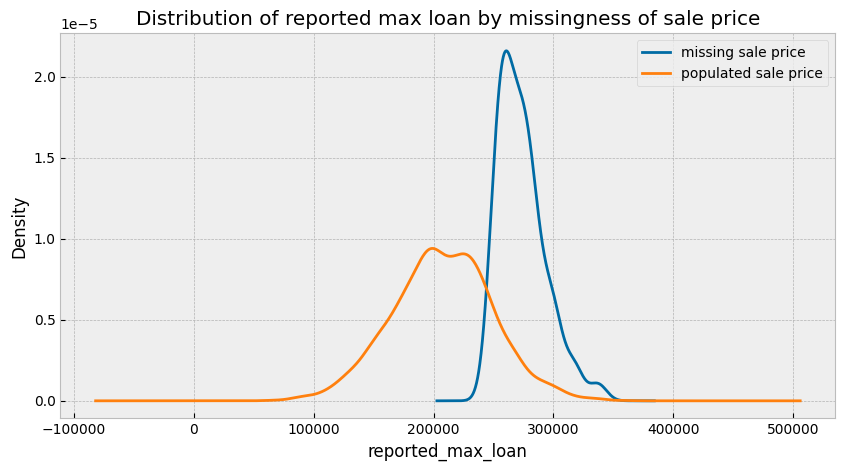

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
ames.query("sale_price.isna()").reported_max_loan.plot(kind='kde', label='missing sale price')
ames.query("sale_price.notna()").reported_max_loan.plot(kind='kde', label='populated sale price')
ax.set_xlabel("reported_max_loan")
ax.set_title("Distribution of reported max loan by missingness of sale price")
ax.legend();

You can see that when `sale_price` is missing, `reported_max_loan` tends to be higher. If there is a pattern in the missingness of a feature then we can exclude that feature being MCAR. Unfortunately, without further knowledge, we can't state if the feature is MNAR, for instance if, given the same `reported_max_loan` value, lower `sale_price` are more likely to be missing. 

MCAR: missingness is random, so imputation mostly helps keep sample size and reduce variance.

MAR: missingness depends on other observed features, so you can recover information by modeling it, and ignoring it can bias the model because the missing group is systematically different.


### 7. Perfect Correlation / Anti-Correlation

Highly correlated features are often **redundant**: they add little new signal, increase complexity, and can destabilize interpretation without improving predictive power. 

Pearson correlation captures linear pairwise relationships only. Tools like Mutual Information can reveal non-linear dependencies.

In [66]:
(ames.select_dtypes('number').corr().unstack().rename('correlation').reset_index()
 .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2'})
 .query('feature_1 != feature_2')
 .assign(abs_correlation=lambda df: df.correlation.abs())
 .assign(pair_of_features=lambda df: df.apply(lambda row: tuple(sorted([row.feature_1, row.feature_2])), axis=1))
 .drop_duplicates('pair_of_features', ignore_index=True)
 .query("abs_correlation>0.99"))


,feature_1,feature_2,correlation,abs_correlation,pair_of_features
19,gr_liv_area,gr_liv_area_m2,1.000000,1.000000,"(gr_liv_area, gr_liv_area_m2)"
75,sale_price,reported_max_loan,0.999761,0.999761,"(reported_max_loan, sale_price)"
81,total_enclosed_area_sqft,total_enclosed_area_m2,1.000000,1.000000,"(total_enclosed_area_m2, total_enclosed_area_s..."


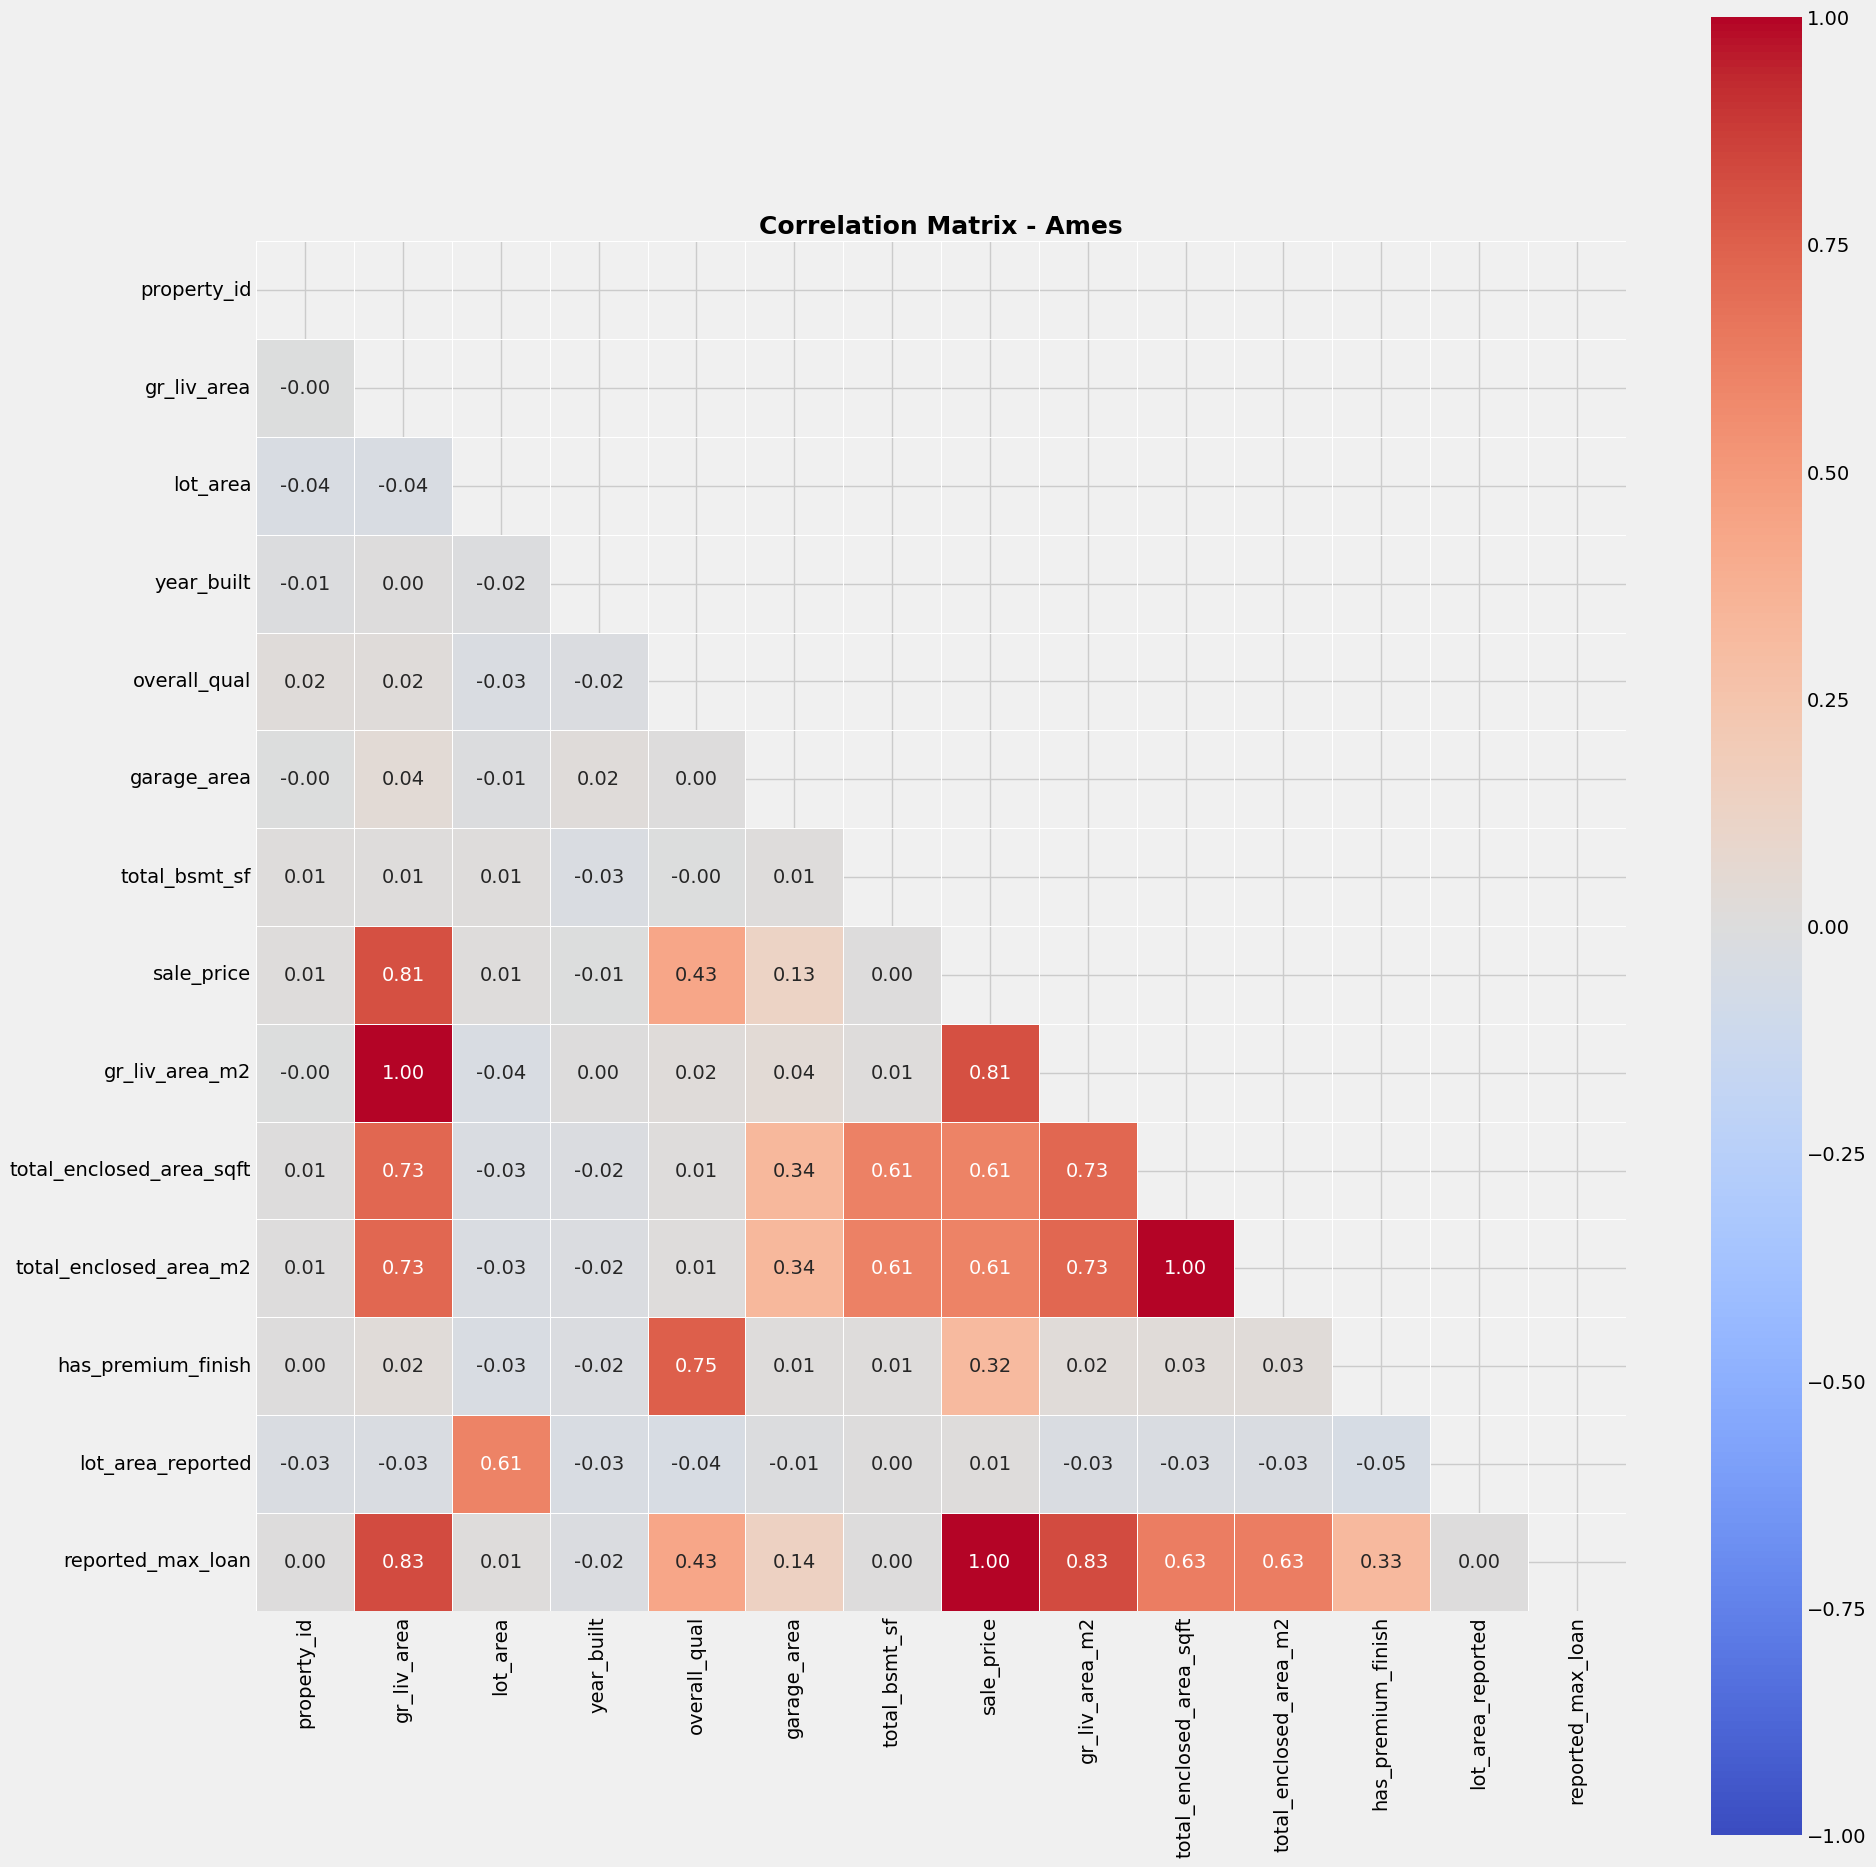

In [10]:
plt.style.use('fivethirtyeight')
corr_matrix = ames.select_dtypes("number").corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(20, 20))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f",
    linewidths=0.5,
    square=True,
    ax=ax,
)

ax.set_title("Correlation Matrix - Ames", fontsize=18, fontweight="bold")
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()


In [71]:
EPS = 1e-3
rows = []

def pick(df, *cands):
    for c in cands:
        if c in df.columns:
            return c
    return None

def check_formula(df, name, lhs_col, rhs_series):
    lhs = pd.to_numeric(df[lhs_col], errors="coerce")
    rhs = pd.to_numeric(rhs_series, errors="coerce")
    mask = lhs.notna() & rhs.notna()
    if mask.sum() == 0:
        return
    resid = (lhs[mask] - rhs[mask]).abs()
    rows.append({
        "formula": name,
        "rows_used": int(mask.sum()),
        "max_abs_resid": float(resid.max()),
        "mean_abs_resid": float(resid.mean()),
        "is_linear_combo": bool(float(resid.max()) <= EPS),
    })

a = pick(ames, "gr_liv_area", "grlivarea")
b = pick(ames, "total_bsmt_sf", "totalbsmtsf")
g = pick(ames, "garage_area", "garagearea")

if a and "gr_liv_area_m2" in ames.columns:
    check_formula(
        ames,
        "gr_liv_area_m2 = 0.09290304 * gr_liv_area",
        "gr_liv_area_m2",
        pd.to_numeric(ames[a], errors="coerce") * 0.09290304,
    )

if a and b and g and "total_enclosed_area_sqft" in ames.columns:
    check_formula(
        ames,
        "total_enclosed_area_sqft = gr_liv_area + total_bsmt_sf + garage_area",
        "total_enclosed_area_sqft",
        pd.to_numeric(ames[a], errors="coerce")
        + pd.to_numeric(ames[b], errors="coerce")
        + pd.to_numeric(ames[g], errors="coerce"),
    )

if "total_enclosed_area_m2" in ames.columns and "total_enclosed_area_sqft" in ames.columns:
    check_formula(
        ames,
        "total_enclosed_area_m2 = 0.09290304 * total_enclosed_area_sqft",
        "total_enclosed_area_m2",
        pd.to_numeric(ames["total_enclosed_area_sqft"], errors="coerce") * 0.09290304,
    )

if "retail" in globals() and {"full_price_pct", "promotion_discount_pct"}.issubset(retail.columns):
    check_formula(
        retail,
        "full_price_pct = 100 - promotion_discount_pct",
        "full_price_pct",
        100 - pd.to_numeric(retail["promotion_discount_pct"], errors="coerce"),
    )

pd.DataFrame(rows).sort_values("max_abs_resid").reset_index(drop=True)


,formula,rows_used,max_abs_resid,mean_abs_resid,is_linear_combo
0,full_price_pct = 100 - promotion_discount_pct,20966,1.421085e-14,9.371710e-17,True
1,gr_liv_area_m2 = 0.09290304 * gr_liv_area,2700,4.992000e-05,2.489161e-05,True
2,total_enclosed_area_m2 = 0.09290304 * total_enclosed_area_sqft,2700,4.992000e-05,2.492249e-05,True
3,total_enclosed_area_sqft = gr_liv_area + total_bsmt_sf + garage_area,2463,1.812000e+03,6.955745e+00,False


### 8. Missing Values Correlation

Here it would be nice to show how 2 non-correlated variables might be very correlated when considering missing values.

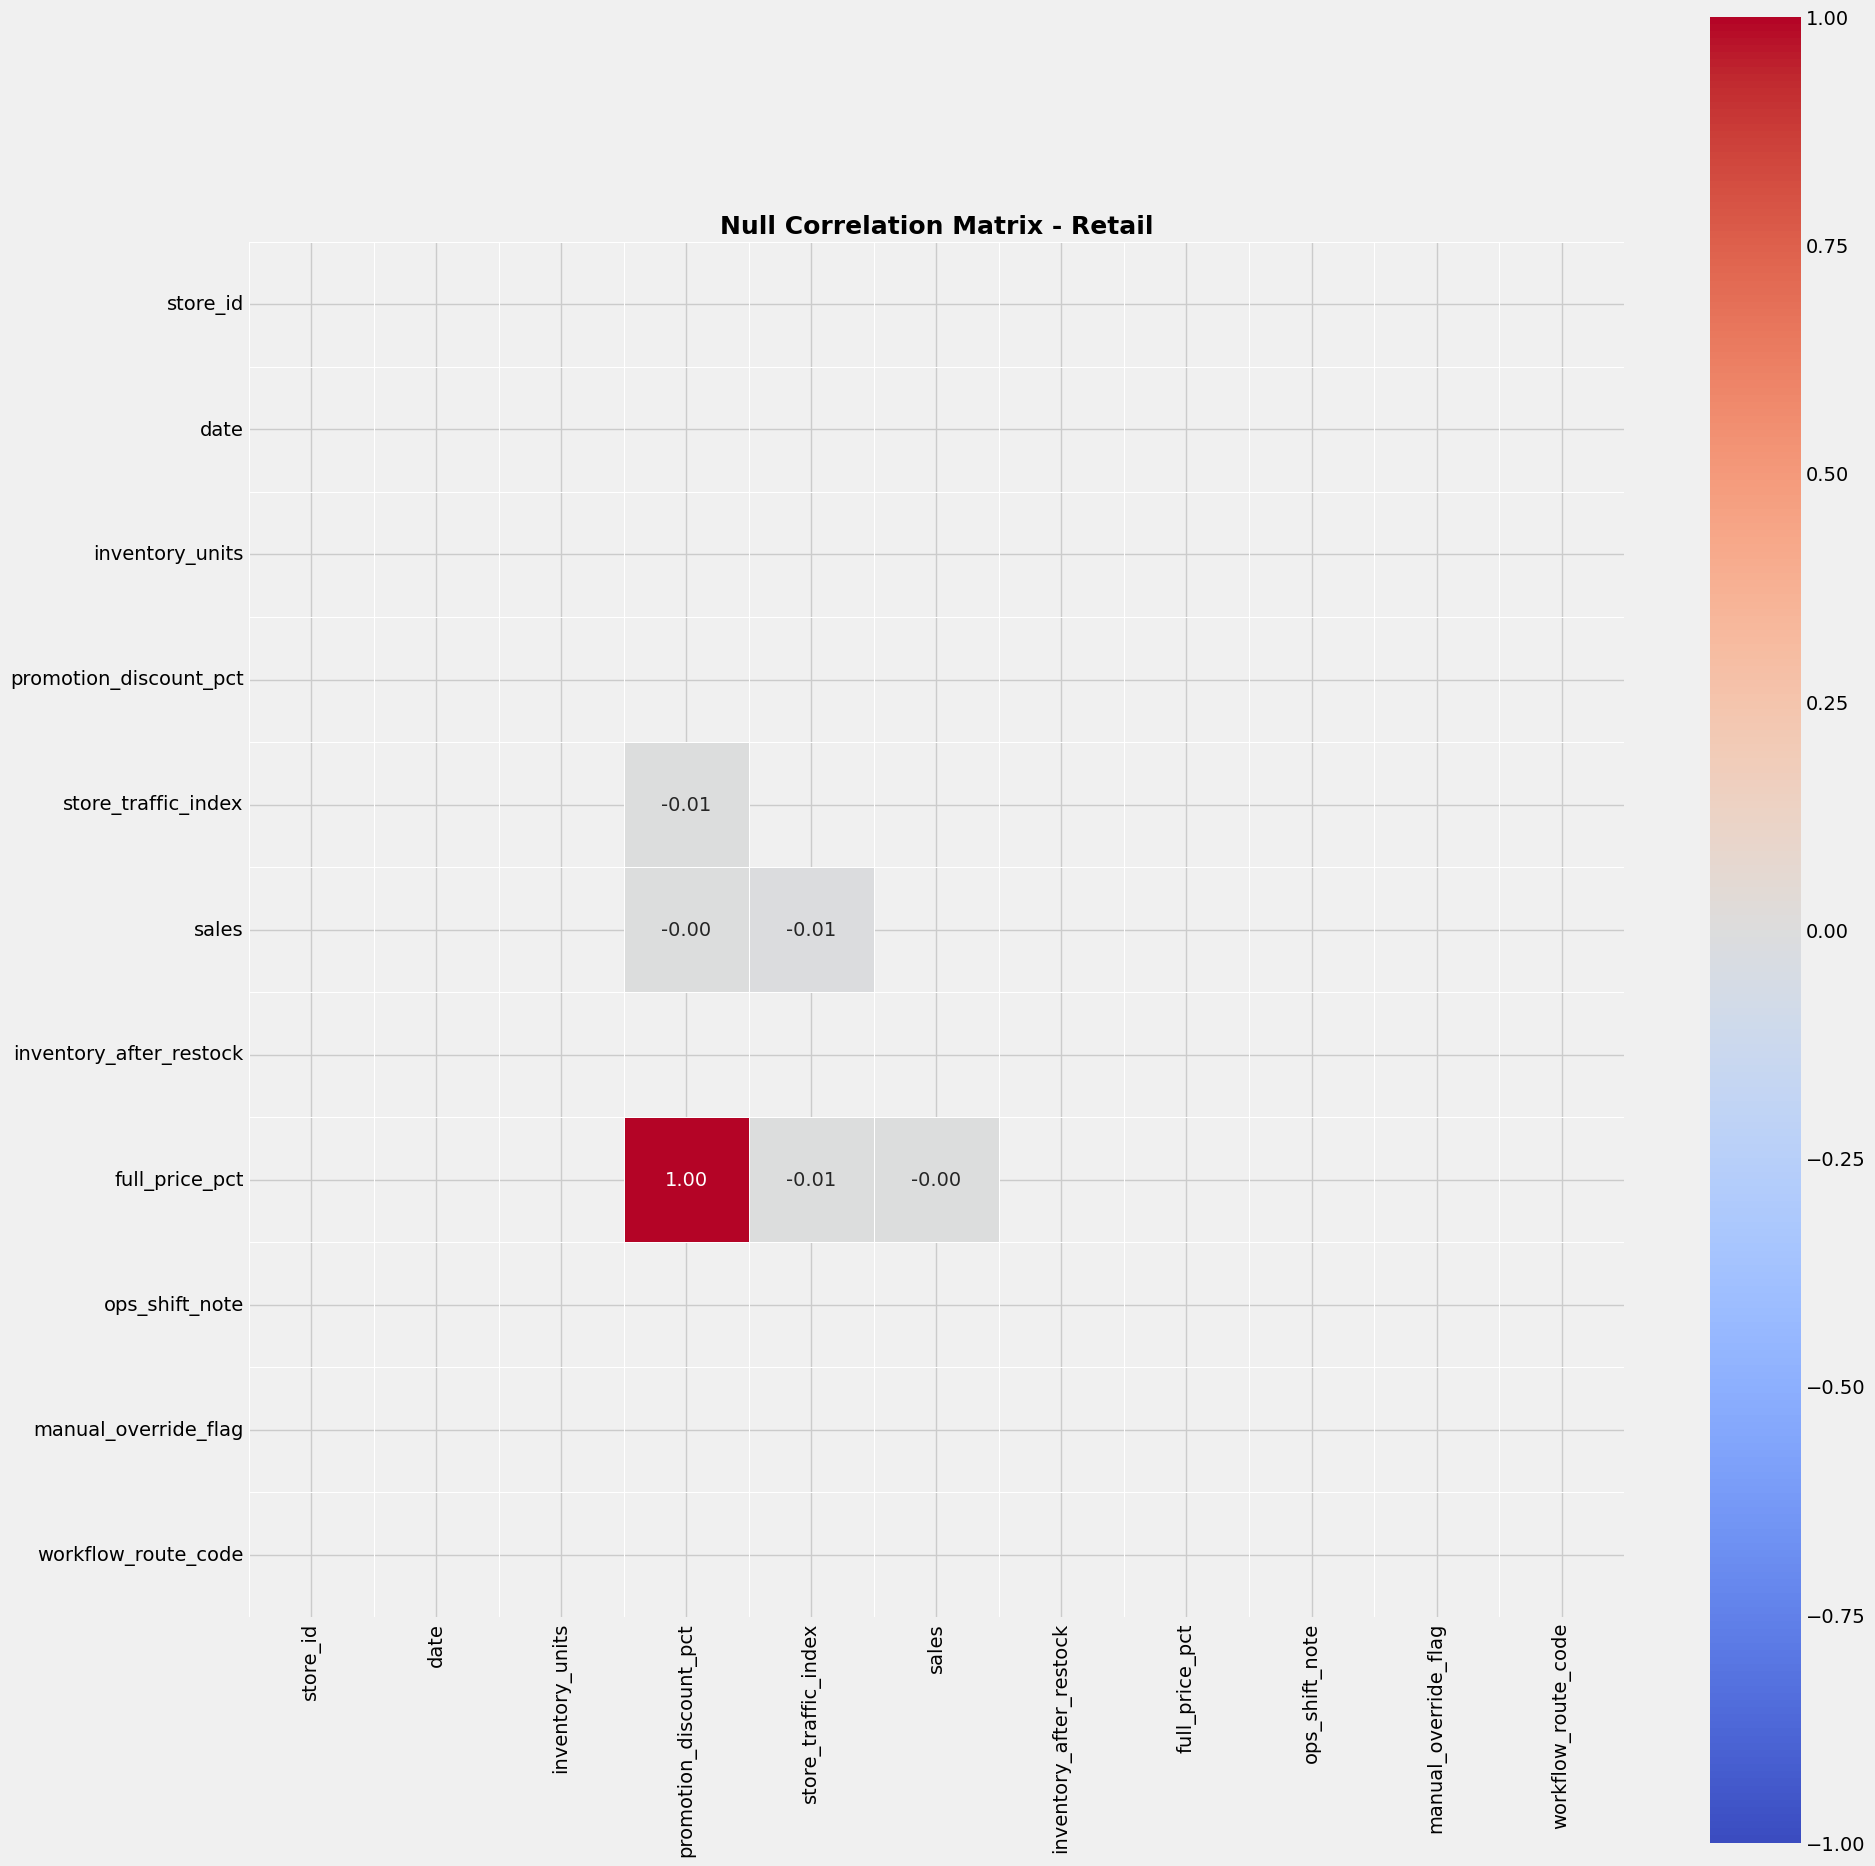

In [16]:
null_corr_matrix = retail.isna().astype(int).corr()

mask = np.triu(np.ones_like(null_corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(20, 20))
sns.heatmap(
    null_corr_matrix,
    mask=mask,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f",
    linewidths=0.5,
    square=True,
    ax=ax,
)

ax.set_title("Null Correlation Matrix - Retail", fontsize=18, fontweight="bold")
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()


In [18]:
retail.query("(full_price_pct.isna() & promotion_discount_pct.notna()) | (full_price_pct.notna() & promotion_discount_pct.isna())")

,store_id,date,inventory_units,promotion_discount_pct,store_traffic_index,sales,inventory_after_restock,full_price_pct,ops_shift_note,manual_override_flag,workflow_route_code


### 9. Rare Categories

In [19]:
# Adult: rare categories in occupation
freq = adult["occupation"].value_counts(dropna=False)
rare = freq[freq <= 20]  # threshold you can tune

print("Rare categories (<=20 rows):")
print(rare)


Rare categories (<=20 rows):
occupation
Court reporter                   15
Geospatial surveyor              15
Aircraft painter                 15
Respiratory therapist            15
Marine electronics technician    14
Other-relative                   14
Not-in-family                    13
Own-child                        13
Unmarried                        12
Husband                          11
Wife                             11
Orthotic fitter                   7
Food safety inspector             6
Name: count, dtype: int64


### 10. Unit inconsistencies

In [26]:
lot_col = "lot_area" 

ratio = ames["lot_area_reported"] / ames[lot_col]

likely_sqm = ratio.between(0.09, 0.095, inclusive="both")
likely_sqft = ratio.between(0.99, 1.01, inclusive="both")

show(
    ames.loc[likely_sqm, ["property_id", lot_col, "lot_area_reported"]].head(20)
)


+----+---------------+------------+---------------------+
|    |   property_id |   lot_area |   lot_area_reported |
|----+---------------+------------+---------------------|
|  7 |             8 |       9561 |              888.25 |
| 13 |            14 |       8875 |              824.51 |
| 25 |            26 |       3660 |              340.02 |
| 29 |            30 |      13969 |             1297.76 |
| 30 |            31 |      10525 |              977.8  |
+----+---------------+------------+---------------------+


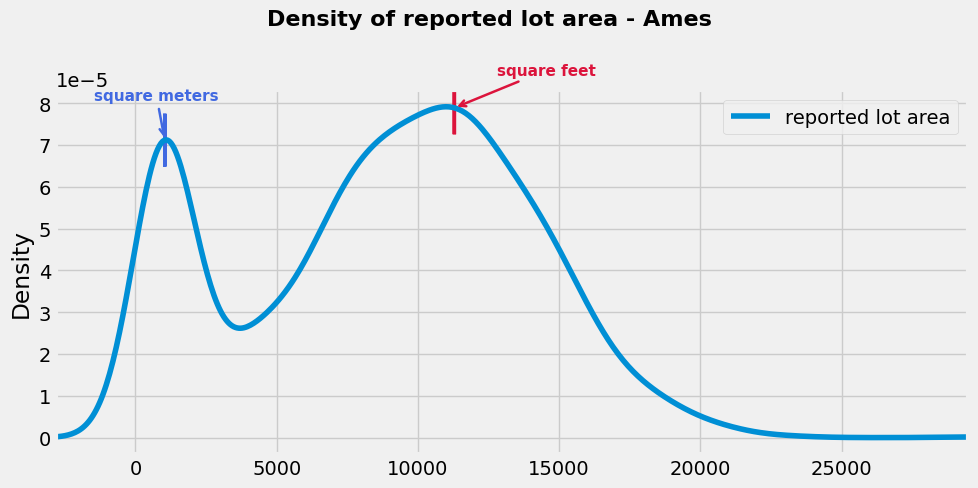

In [34]:
from matplotlib.patches import Circle

fig, ax = plt.subplots(figsize=(10, 5))
ames["lot_area_reported"].plot(kind="kde", ax=ax, label="reported lot area")

x_min = ames["lot_area_reported"].min() - 3000
x_max = ames["lot_area_reported"].max()
ax.set_xlim(x_min, x_max)

x = ames["lot_area_reported"].dropna().to_numpy()
counts, bins = np.histogram(x, bins=120)
centers = (bins[:-1] + bins[1:]) / 2

left_mask = centers < np.nanmedian(x)
right_mask = ~left_mask

sqm_mode_x = centers[left_mask][np.argmax(counts[left_mask])]
sqft_mode_x = centers[right_mask][np.argmax(counts[right_mask])]

kde_line = ax.lines[0]
xk, yk = kde_line.get_xdata(), kde_line.get_ydata()
sqm_mode_y = np.interp(sqm_mode_x, xk, yk)
sqft_mode_y = np.interp(sqft_mode_x, xk, yk)

ymax = max(yk)
r = ymax * 0.08
ax.add_patch(Circle((sqm_mode_x, sqm_mode_y), r, fill=False, ec="royalblue", lw=2.5))
ax.add_patch(Circle((sqft_mode_x, sqft_mode_y), r, fill=False, ec="crimson", lw=2.5))

ax.annotate("square meters", xy=(sqm_mode_x, sqm_mode_y), xytext=(sqm_mode_x - 2500, sqm_mode_y + ymax*0.12),
            arrowprops=dict(arrowstyle="->", color="royalblue", lw=1.8),
            color="royalblue", fontsize=11, fontweight="bold")
ax.annotate("square feet", xy=(sqft_mode_x, sqft_mode_y), xytext=(sqft_mode_x + 1500, sqft_mode_y + ymax*0.10),
            arrowprops=dict(arrowstyle="->", color="crimson", lw=1.8),
            color="crimson", fontsize=11, fontweight="bold")

ax.legend()
fig.suptitle("Density of reported lot area - Ames", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

